In [ ]:
import os


files = os.listdir(".")
print(files)

['ecg_analysis.ipynb', 'MaxC ECG data.txt']


In [ ]:
import pandas as pd

data_file = "MaxC ECG data.txt" 
df = pd.read_csv(data_file, sep="\t")  
df.head()  

,Time,ECG Record Lead aVF,ECG Record Lead aVL,ECG Record Lead aVR,ECG Record Lead I,ECG Record Lead II,ECG Record Lead III,Cevis Target Load,Unnamed: 8
0,0,-0.444883,0.085488,0.359390,-0.181348,-0.535557,-0.354219,50,NaN
1,5,-0.420898,0.097383,0.323516,-0.149648,-0.494844,-0.345234,50,NaN
2,10,-0.270820,0.070000,0.200820,-0.086387,-0.312773,-0.226387,50,NaN
3,15,-0.156523,0.049131,0.107422,-0.038281,-0.174922,-0.136563,50,NaN
4,20,-0.055273,0.016387,0.038887,-0.015000,-0.062773,-0.047773,50,NaN


Index(['Time', 'ECG Record Lead aVF', 'ECG Record Lead aVL',
       'ECG Record Lead aVR', 'ECG Record Lead I', 'ECG Record Lead II',
       'ECG Record Lead III', 'Cevis Target Load', 'Unnamed: 8'],
      dtype='str')


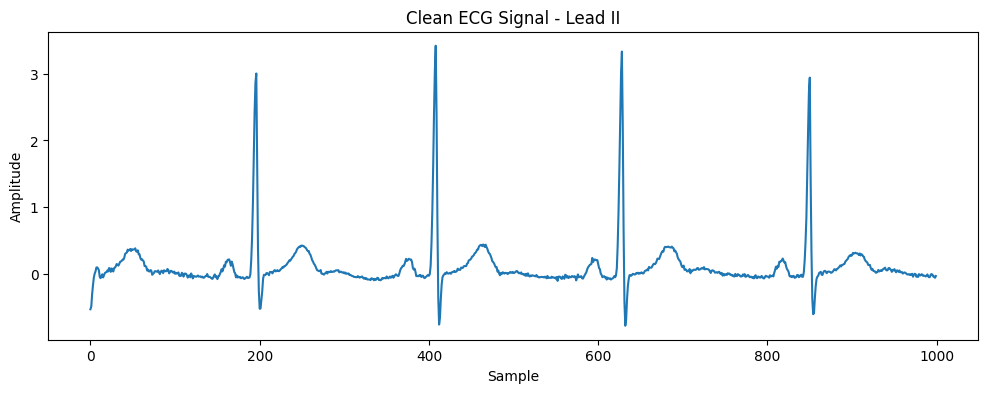

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load clean data
data_file = "MaxC ECG data.txt"  
df = pd.read_csv(data_file, sep="\t")  

# Vælg kolonne til analyse

print(df.columns)

signal = df['ECG Record Lead II']

# Plot et udsnit af signalet
plt.figure(figsize=(12,4))
plt.plot(signal[:1000])  # første 1000 samples
plt.title("Clean ECG Signal - Lead II")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()

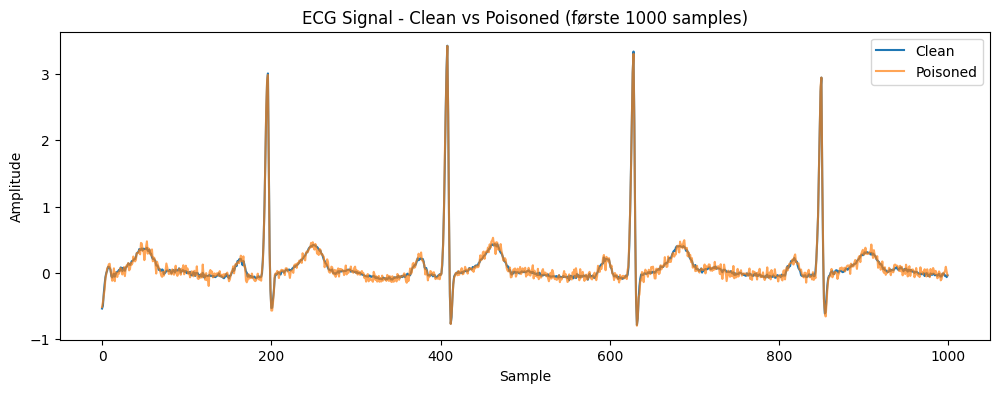

In [6]:
import numpy as np

# Lav en kopi af clean signal
poisoned_signal = signal.copy()

# Tilføj støj (f.eks. normalfordelt med lille standardafvigelse)
noise = np.random.normal(0, 0.05, size=len(signal))  # 0.05 er støjstyrke
poisoned_signal += noise

# Plot clean vs poisoned
plt.figure(figsize=(12,4))
plt.plot(signal[:1000], label='Clean')
plt.plot(poisoned_signal[:1000], label='Poisoned', alpha=0.7)
plt.title("ECG Signal - Clean vs Poisoned (første 1000 samples)")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

In [8]:
# Gem som csv, så du kan bruge det senere i modeller
poisoned_df = pd.DataFrame({
    'Lead II Clean': signal,
    'Lead II Poisoned': poisoned_signal
})
poisoned_df.to_csv("poisoned_data.csv", index=False)